In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import mols2grid
import base64
import io
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, rdDepictor, PandasTools
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem.Scaffolds import MurckoScaffold
from IPython.display import HTML
from typing import List, Dict, Set, Tuple

## Download molecules with specific properties from chembl

In [3]:
import requests
import time
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
from rdkit.Chem.MolStandardize import rdMolStandardize

def download_filtered_chembl_activities(
    output_sdf: str = "../data/filtered_chembl_v1.sdf",
    output_csv: str = "../data/filtered_chembl_activities_v1.csv",
    #pchembl_min: float = 6.0, #remove this for morpheus fragment library
    #assay_confidence_min: int = 8, #remove this for morpheus fragment library
    mw_range: Tuple[float, float] = (150, 650),
    logp_min: float = -1.0,
    logp_max: float = 5.0,
    rotatable_bonds_max: int = 8,
    allowed_atoms: Set[str] = {'C', 'S', 'O', 'N', 'H', 'F', 'Cl', 'Br'},
    max_total_records: int = None,
    batch_size: int = 1000,
    verbose: bool = True
) -> Tuple[int, pd.DataFrame]:
    """
    Download ChEMBL molecules with bioactivity data using the ChEMBL REST API.
    
    Filters applied:
        - pChEMBL value >= pchembl_min (default 6.0) #removed for morpheus fragment library
        - Assay confidence score >= assay_confidence_min (default 8) #removed for morpheus fragment library
        - Molecular weight in mw_range (default 150-650 Da)
        - LogP in logp_range (default -1.0 to 5.0)
        - Rotatable bonds <= rotatable_bonds_max (default 8)
        - Only allowed atoms (default: C, S, O, N, H, F, Cl, Br)
    
    Molecules are standardized and neutralized before physicochemical filtering.
    
    Returns:
        Tuple of (number of molecules saved, DataFrame with activity data)
    """
    
    base_url = "https://www.ebi.ac.uk/chembl/api/data/activity.json"
    
    # Initialize standardization tools
    normalizer = rdMolStandardize.Normalizer()
    uncharger = rdMolStandardize.Uncharger()
    largest_fragment = rdMolStandardize.LargestFragmentChooser()
    
    def standardize_and_neutralize(mol):
        if mol is None:
            return None
        try:
            mol = largest_fragment.choose(mol)
            mol = normalizer.normalize(mol)
            mol = uncharger.uncharge(mol)
            return mol
        except:
            return None
    
    def check_allowed_atoms(mol, allowed: Set[str]) -> bool:
        for atom in mol.GetAtoms():
            if atom.GetSymbol() not in allowed:
                return False
        return True
    
    def passes_filters(mol, mw_min, mw_max, logp_min, logp_max, rot_max, allowed) -> bool:
        if mol is None:
            return False
        if not check_allowed_atoms(mol, allowed):
            return False
        mw = Descriptors.MolWt(mol)
        if mw < mw_min or mw > mw_max:
            return False
        logp = Descriptors.MolLogP(mol)
        if logp < logp_min or logp > logp_max:
            return False
        rot_bonds = rdMolDescriptors.CalcNumRotatableBonds(mol)
        if rot_bonds > rot_max:
            return False
        return True
    
    seen_chembl_ids = set()
    activity_records = []
    writer = Chem.SDWriter(output_sdf)
    
    offset = 0
    total_processed = 0
    total_saved = 0
    
    if verbose:
        print(f"Starting ChEMBL download with filters:")
        #print(f"  - pChEMBL >= {pchembl_min} #removed for morpheus fragment library")
        #print(f"  - Assay confidence >= {assay_confidence_min} #removed for morpheus fragment library")
        print(f"  - MW: {mw_range[0]}-{mw_range[1]} Da")
        print(f"  - LogP: {logp_min} to {logp_max}")
        print(f"  - Rotatable bonds <= {rotatable_bonds_max}")
        print(f"  - Allowed atoms: {allowed_atoms}\n")
    
    try:
        while True:
            params = {
                #'pchembl_value__gte': pchembl_min,
                #'assay_confidence_score__gte': assay_confidence_min,
                'limit': batch_size,
                'offset': offset
            }
            
            for attempt in range(3):
                try:
                    response = requests.get(base_url, params=params, timeout=60)
                    response.raise_for_status()
                    break
                except requests.exceptions.RequestException as e:
                    if attempt < 2:
                        if verbose:
                            print(f"  Request failed, retrying ({attempt + 1}/3)...")
                        time.sleep(5)
                    else:
                        raise e
            
            data = response.json()
            activities = data.get('activities', [])
            
            if not activities:
                if verbose:
                    print(f"No more activities found at offset {offset}")
                break
            
            batch_saved = 0
            
            for activity in activities:
                total_processed += 1
                
                smiles = activity.get('canonical_smiles')
                chembl_id = activity.get('molecule_chembl_id')
                
                if not smiles or not chembl_id:
                    continue
                if chembl_id in seen_chembl_ids:
                    continue
                
                mol = Chem.MolFromSmiles(smiles)
                if mol is None:
                    continue
                
                mol = standardize_and_neutralize(mol)
                if mol is None:
                    continue
                
                if not passes_filters(mol, mw_range[0], mw_range[1], logp_min, logp_max,
                                     rotatable_bonds_max, allowed_atoms):
                    continue
                
                seen_chembl_ids.add(chembl_id)
                
                mw = Descriptors.MolWt(mol)
                logp = Descriptors.MolLogP(mol)
                rot_bonds = rdMolDescriptors.CalcNumRotatableBonds(mol)
                
                mol.SetProp('chembl_id', chembl_id)
                mol.SetProp('pchembl_value', str(activity.get('pchembl_value', '')))
                mol.SetProp('assay_confidence_score', str(activity.get('assay_confidence_score', '')))
                mol.SetProp('assay_chembl_id', str(activity.get('assay_chembl_id', '')))
                mol.SetProp('target_chembl_id', str(activity.get('target_chembl_id', '')))
                mol.SetProp('standard_type', str(activity.get('standard_type', '')))
                mol.SetProp('standard_value', str(activity.get('standard_value', '')))
                mol.SetProp('standard_units', str(activity.get('standard_units', '')))
                mol.SetDoubleProp('mw', mw)
                mol.SetDoubleProp('logp', logp)
                mol.SetIntProp('rotatable_bonds', rot_bonds)
                
                writer.write(mol)
                total_saved += 1
                batch_saved += 1
                
                activity_records.append({
                    'chembl_id': chembl_id,
                    'smiles': Chem.MolToSmiles(mol),
                    'pchembl_value': activity.get('pchembl_value'),
                    'assay_confidence_score': activity.get('assay_confidence_score'),
                    'assay_chembl_id': activity.get('assay_chembl_id'),
                    'target_chembl_id': activity.get('target_chembl_id'),
                    'standard_type': activity.get('standard_type'),
                    'standard_value': activity.get('standard_value'),
                    'standard_units': activity.get('standard_units'),
                    'mw': mw,
                    'logp': logp,
                    'rotatable_bonds': rot_bonds
                })
            
            if verbose:
                print(f"Processed {total_processed} activities, saved {total_saved} unique molecules (+{batch_saved})")
            
            if max_total_records and total_processed >= max_total_records:
                if verbose:
                    print(f"Reached maximum record limit ({max_total_records})")
                break
            
            if data.get('page_meta', {}).get('next') is None and len(activities) < batch_size:
                if verbose:
                    print("Reached end of results")
                break
            
            offset += batch_size
            time.sleep(0.5)
    
    finally:
        writer.close()
    
    df = pd.DataFrame(activity_records)
    df.to_csv(output_csv, index=False)
    
    if verbose:
        print(f"\n{'='*60}")
        print(f"Download complete!")
        print(f"  Total activities processed: {total_processed}")
        print(f"  Unique molecules saved: {total_saved}")
        print(f"  SDF file: {output_sdf}")
        print(f"  CSV file: {output_csv}")
        print(f"{'='*60}")
    
    return total_saved, df

Execute the above function to download the molecules

In [4]:
# # Test with 10,000 records first (remove max_total_records for full download)
# num_mols, activity_df = download_filtered_chembl_activities(
#     #max_total_records=10000  # Comment this line for full ChEMBL download
# )

# print(f"\nDataFrame shape: {activity_df.shape}")
# activity_df.head(10)

In [ ]:
#load the sdf file
df = PandasTools.LoadSDF("../data/filtered_chembl_v1.sdf")
print(df.shape[0])

[13:28:23] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 4 ignored
[13:28:23] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 11 ignored
[13:28:23] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 18 ignored
[13:28:23] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 21 ignored
[13:28:23] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 24 ignored
[13:28:24] Warning: ambiguous stereochemistry - zero final chiral volume - at atom 24 ignored
[13:28:24] Warning: ambiguous stereochemistry - zero final chiral volume - at atom 22 ignored
[13:28:24] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 23 ignored
[13:28:26] Warning: ambiguous stereochemistry - zero final chiral volume - at atom 9 ignored
[13:28:30] Warning: ambiguous stereochemistry - zero final chiral volume - at atom 9 ignored
[13:28:30] Warning: ambiguous stereochemistry - zero final chiral volume - 

738041


The downloaded dataset is saved as `whole_filtered_chembl.sdf`

Now, we convert the SDF to CSV and also derived SMILES and mol columns

In [ ]:
# Load SDF file with RDKit
# df = PandasTools.LoadSDF("../data/filtered_chembl_v1.sdf", molColName='ROMol', includeFingerprints=False)
# print(f"Loaded {len(df)} molecules from SDF")

# Generate SMILES from ROMol objects
def safe_mol_to_smiles(mol):
    if mol is None:
        return pd.NA
    try:
        smiles = Chem.MolToSmiles(mol, canonical=True)
        return smiles if smiles else pd.NA
    except:
        return pd.NA

df['SMILES'] = df['ROMol'].apply(safe_mol_to_smiles)

# Count valid SMILES
valid_count = df['SMILES'].notna().sum()
na_count = df['SMILES'].isna().sum()
print(f"Generated SMILES: {valid_count} valid, {na_count} NA")

Generated SMILES: 738041 valid, 0 NA


In [21]:
# Save to CSV (excluding ROMol column as it can't be serialized directly)
# Keep all other columns plus SMILES
csv_columns = [col for col in df.columns if col != 'ROMol'] # Exclude 'ROMol' from CSV
df[csv_columns].to_csv("../data/whole_filtered_chembl_v1.csv", index=False) # Save CSV with SMILES
print(f"Saved to ../data/whole_filtered_chembl_v1.csv")

df.head()

Saved to ../data/whole_filtered_chembl_v1.csv


,chembl_id,pchembl_value,assay_confidence_score,assay_chembl_id,target_chembl_id,standard_type,standard_value,standard_units,mw,logp,rotatable_bonds,ID,ROMol,SMILES
0,CHEMBL324340,5.60,,CHEMBL872937,CHEMBL3921,IC50,2500.0,nM,398.37400000000014,4.3020200000000033,3,,<rdkit.Chem.rdchem.Mol object at 0x31e7d5770>,Cc1ccc2oc(-c3cccc(N4C(=O)c5ccc(C(=O)O)cc5C4=O)...
1,CHEMBL357278,5.40,,CHEMBL760688,CHEMBL4632,IC50,4000.0,nM,543.01100000000008,4.2729200000000036,8,,<rdkit.Chem.rdchem.Mol object at 0x34bf2a9d0>,Cc1nc2cc(OC[C@H](O)CN3CCN(CC(=O)Nc4ccc(Cl)c(C(...
2,CHEMBL416206,None,,CHEMBL824039,CHEMBL612545,Inhibition,47.0,%,297.40200000000004,2.7134000000000009,3,,<rdkit.Chem.rdchem.Mol object at 0x34bf2ba00>,NCCCn1c2c(c3ccccc31)C(=O)CN1CCCCC21
3,CHEMBL33450,None,,CHEMBL824039,CHEMBL612545,Inhibition,38.0,%,391.47100000000023,3.7777000000000029,5,,<rdkit.Chem.rdchem.Mol object at 0x34bf2a960>,O=C(NCCCn1c2c(c3ccccc31)C(=O)CN1CCCCC21)c1ccco1
4,CHEMBL268439,8.22,,CHEMBL873200,CHEMBL261,Ki,6.0,nM,335.39200000000005,-0.43149999999999999,4,,<rdkit.Chem.rdchem.Mol object at 0x34bf2ae30>,Nc1ccc(S(=O)(=O)Nc2nnc(S(N)(=O)=O)s2)cc1


##  Read the compressed .gz chembl database

The .csv created above was converted to .gz, which was then used for all purposes to save some disc space. The csv file, which was of 104Mb was reduced to 23Mb in csv.gz format.

Then, the csv and sdf files were deleted 

In [22]:
# Pandas automatically detects and reads .gz compressed files
df = pd.read_csv("../data/whole_filtered_chembl_v1.csv.gz")

In [23]:
df.shape[0]

738041

In [24]:
df.head(3)

,chembl_id,pchembl_value,assay_confidence_score,assay_chembl_id,target_chembl_id,standard_type,standard_value,standard_units,mw,logp,rotatable_bonds,ID,SMILES
0,CHEMBL324340,5.6,NaN,CHEMBL872937,CHEMBL3921,IC50,2500.0,nM,398.374,4.30202,3,NaN,Cc1ccc2oc(-c3cccc(N4C(=O)c5ccc(C(=O)O)cc5C4=O)...
1,CHEMBL357278,5.4,NaN,CHEMBL760688,CHEMBL4632,IC50,4000.0,nM,543.011,4.27292,8,NaN,Cc1nc2cc(OC[C@H](O)CN3CCN(CC(=O)Nc4ccc(Cl)c(C(...
2,CHEMBL416206,NaN,NaN,CHEMBL824039,CHEMBL612545,Inhibition,47.0,%,297.402,2.71340,3,NaN,NCCCn1c2c(c3ccccc31)C(=O)CN1CCCCC21


In [25]:
#check the number of NA in all columns
df.isna().sum()

chembl_id                      0
pchembl_value             287690
assay_confidence_score    738041
assay_chembl_id                0
target_chembl_id               0
standard_type                 83
standard_value             25293
standard_units             40833
mw                             0
logp                           0
rotatable_bonds                0
ID                        738041
SMILES                         0
dtype: int64

In [26]:
#Hence, we remove assay_confidence_score and ID columns
df = df.drop(columns=['assay_confidence_score', 'ID'])

In [27]:
df.head(3)

,chembl_id,pchembl_value,assay_chembl_id,target_chembl_id,standard_type,standard_value,standard_units,mw,logp,rotatable_bonds,SMILES
0,CHEMBL324340,5.6,CHEMBL872937,CHEMBL3921,IC50,2500.0,nM,398.374,4.30202,3,Cc1ccc2oc(-c3cccc(N4C(=O)c5ccc(C(=O)O)cc5C4=O)...
1,CHEMBL357278,5.4,CHEMBL760688,CHEMBL4632,IC50,4000.0,nM,543.011,4.27292,8,Cc1nc2cc(OC[C@H](O)CN3CCN(CC(=O)Nc4ccc(Cl)c(C(...
2,CHEMBL416206,NaN,CHEMBL824039,CHEMBL612545,Inhibition,47.0,%,297.402,2.71340,3,NCCCn1c2c(c3ccccc31)C(=O)CN1CCCCC21


Check the histogram distribution of all numerical columns

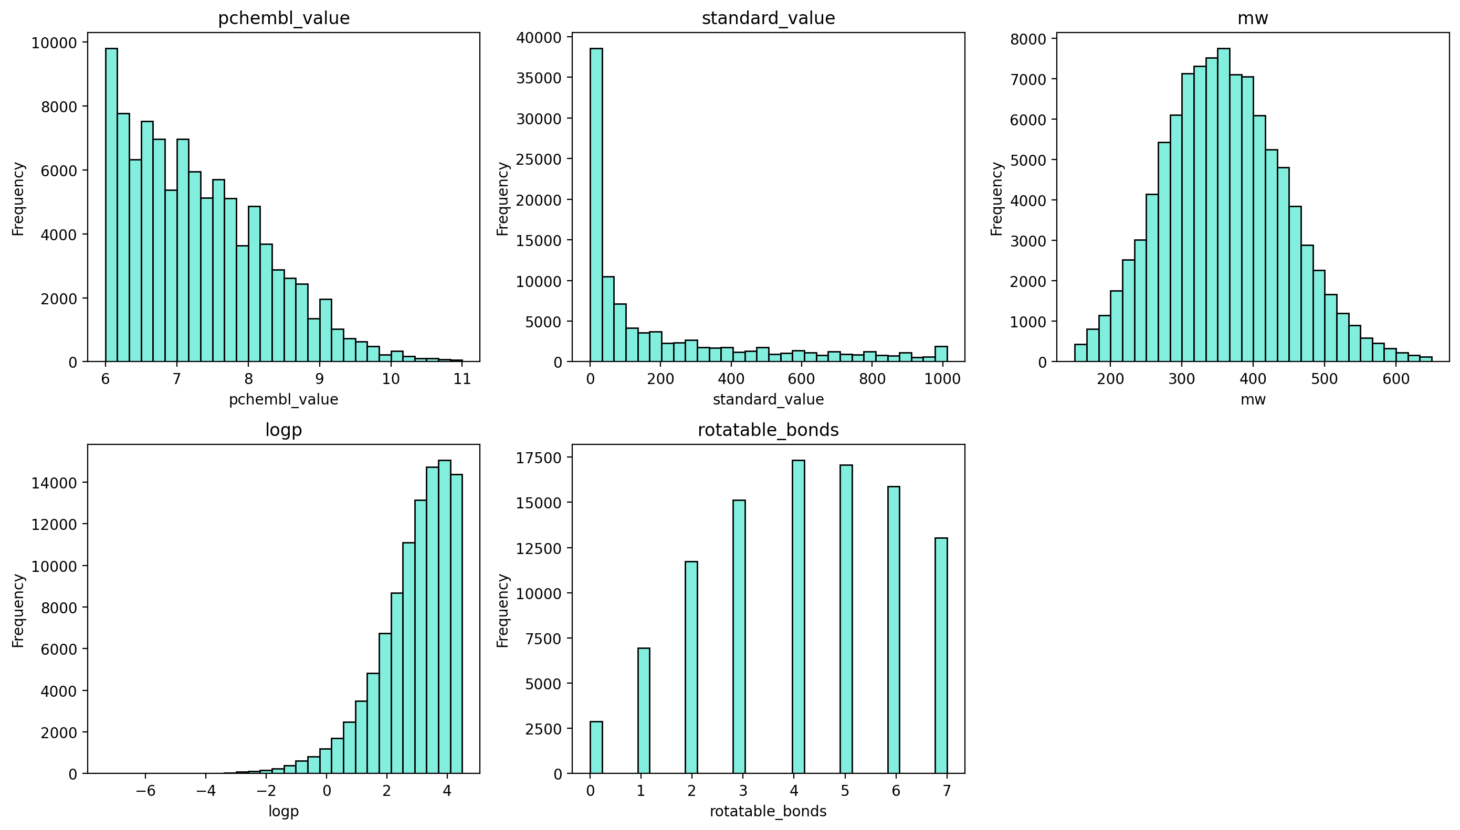

In [28]:
df.standard_units.value_counts()

standard_units
nM            579147
%              61705
ug.mL-1        22513
mg.kg-1         6924
uM              5667
               ...  
M ml-1             1
nM stent-1         1
ug/kg              1
nmol/mg            1
10'-3M             1
Name: count, Length: 400, dtype: int64

In [29]:
df.standard_type.value_counts()

standard_type
Potency                 324265
IC50                    166039
Ki                       55948
Inhibition               37226
EC50                     27724
                         ...  
Max fall in MAP              1
Amount of metabolite         1
Low                          1
Median survival time         1
partition_ratio              1
Name: count, Length: 1452, dtype: int64

Check correlation heatmap between numerical columns

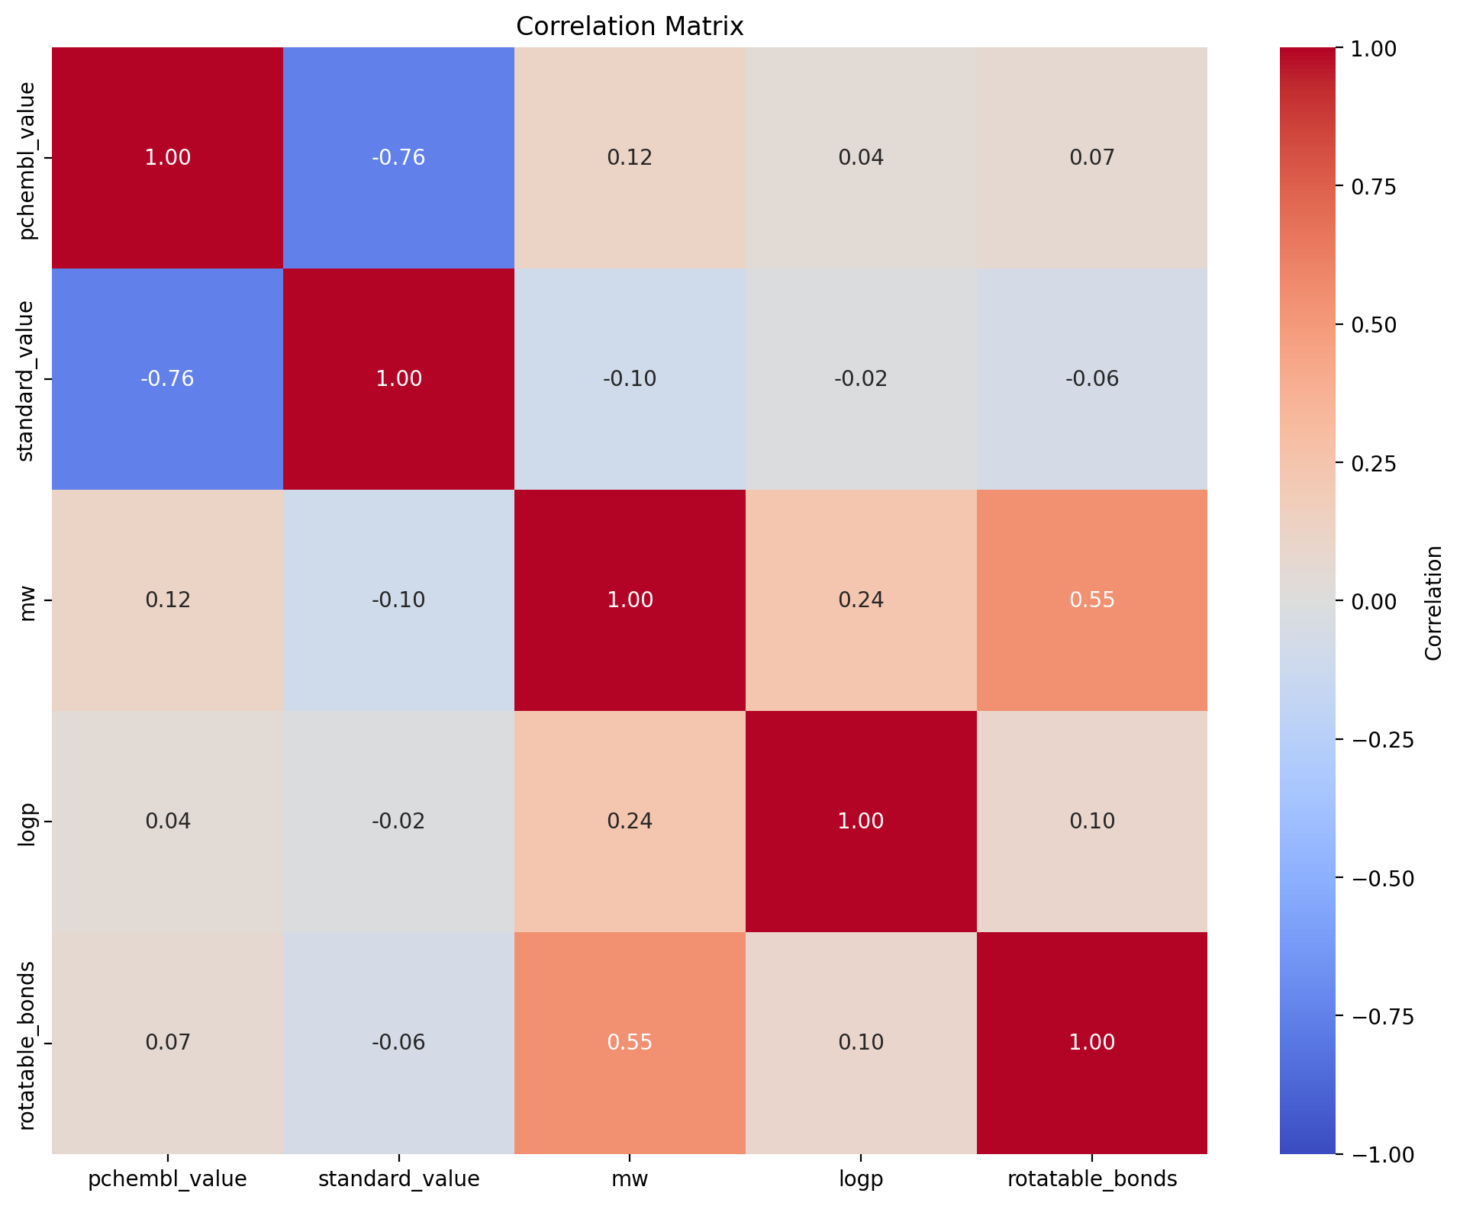

# Search the chembl database

In [ ]:
sub1 = "C12C3C4C1C5C2C3C45" #cubane
#sub1 = "NN"

#Fetch molecules and visualise them containing the above substructure
matches = df['SMILES'].apply(lambda x: Chem.MolFromSmiles(x).HasSubstructMatch(Chem.MolFromSmiles(sub1)) if pd.notna(x) else False)
matched_mols = df[matches]
matched_mols.head(3)

,chembl_id,pchembl_value,assay_chembl_id,target_chembl_id,standard_type,standard_value,standard_units,mw,logp,rotatable_bonds,SMILES
49162,CHEMBL2021372,NaN,CHEMBL719076,CHEMBL3772,Ki,232000.0,nM,221.212,-0.7791,3,N[C@H](C(=O)O)C12C3C4C1C1C2C3C41C(=O)O
137096,CHEMBL17042,NaN,CHEMBL734187,CHEMBL2756,Ki,120000.0,nM,209.292,1.6347,2,NCC12C3C4C1C1C2C3C41c1ccccc1
137683,CHEMBL16608,NaN,CHEMBL734187,CHEMBL2756,Ki,260000.0,nM,173.259,1.0931,2,NCC12C3C4C1C1C2C3C41C1CC1


In [31]:
#Get the smiles and its ChemblIDs

matched_mols['SMILES'].tolist()

['N[C@H](C(=O)O)C12C3C4C1C1C2C3C41C(=O)O',
 'NCC12C3C4C1C1C2C3C41c1ccccc1',
 'NCC12C3C4C1C1C2C3C41C1CC1',
 'O=C(NCC12C3C4C5C3C1C5C42)c1ccc(F)cc1',
 'O=C(NCC12C3C4C5C3C1C5C42)c1ccccc1F',
 'COc1ccc(Cl)c(C(=O)NCC23C4C5C6C4C2C6C53)c1']

Number of molecules matching the substructure C12C3C4C1C5C2C3C45: 6


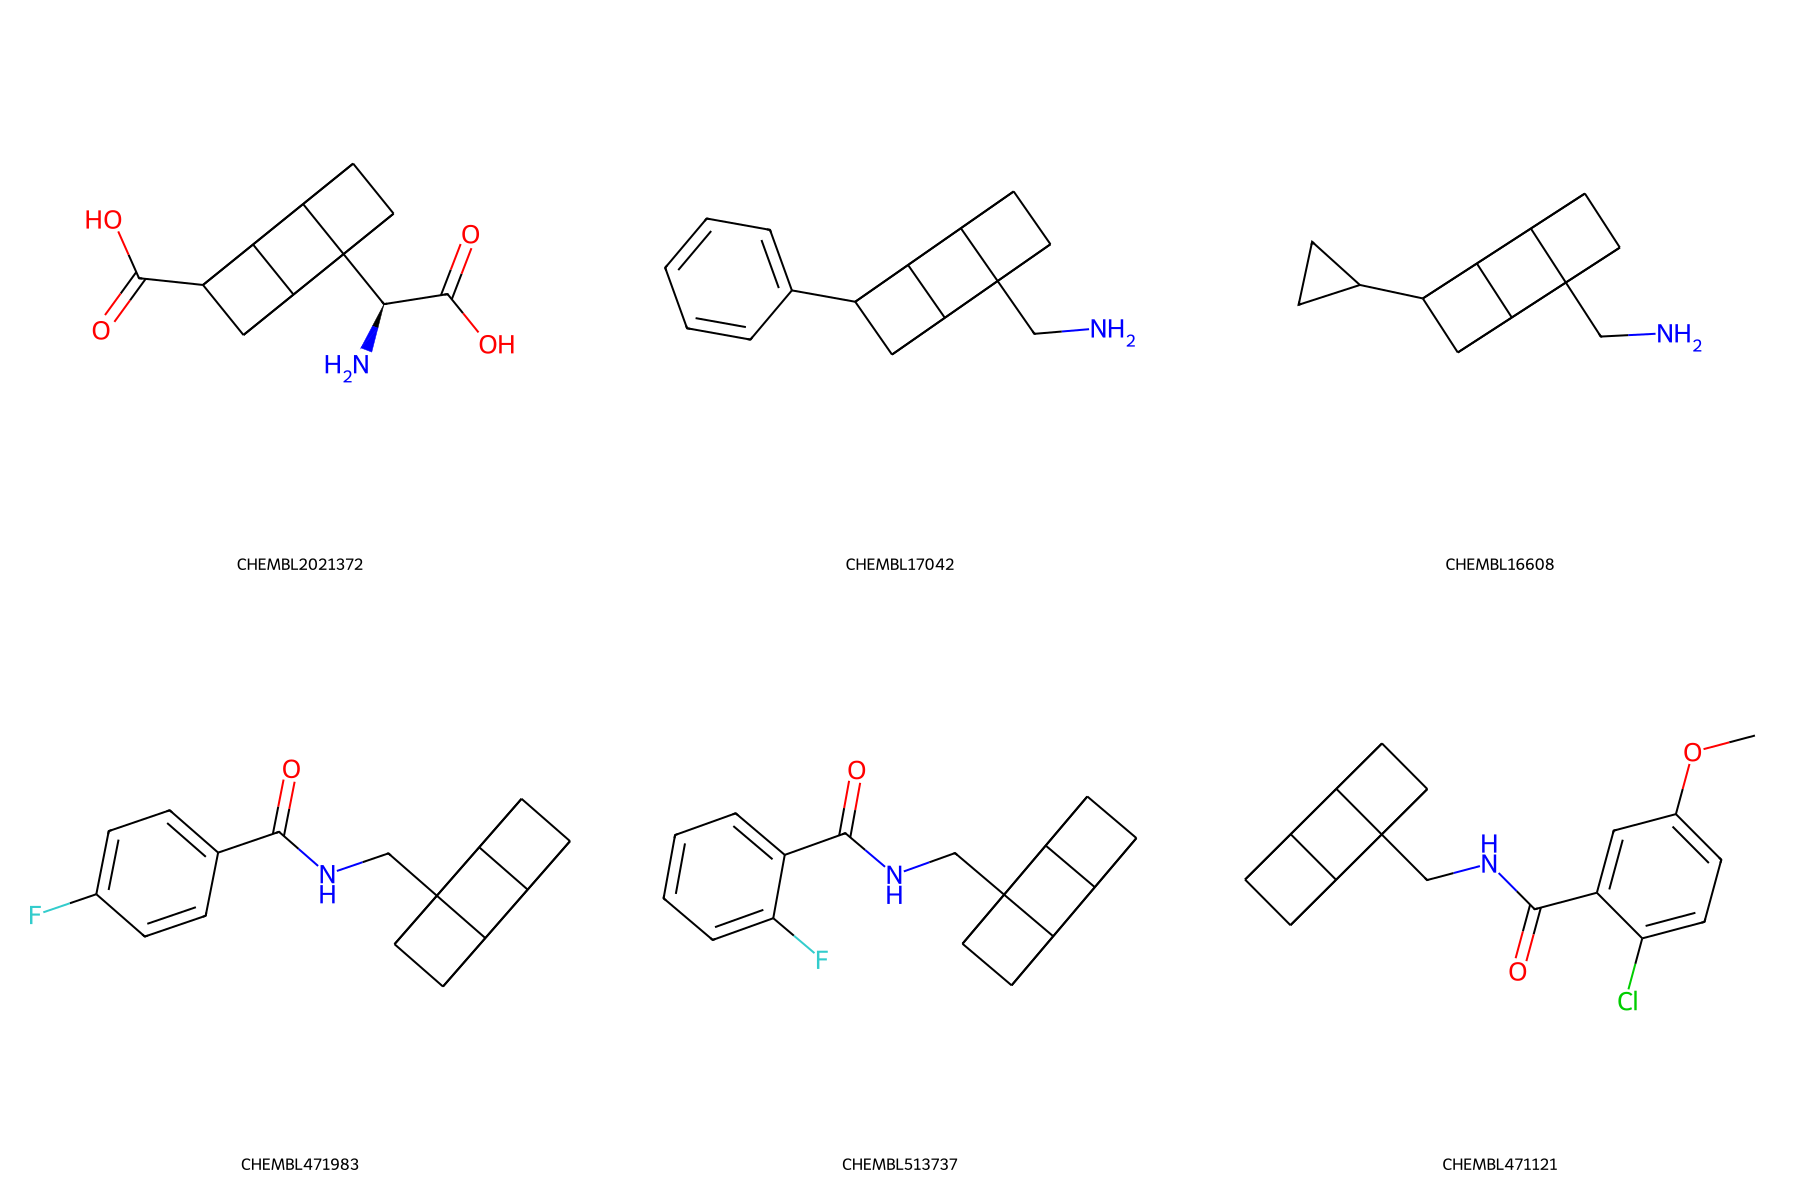

In [32]:
#visualise the matched molecules
print(f"Number of molecules matching the substructure {sub1}: {matched_mols.shape[0]}")
mols = [Chem.MolFromSmiles(smiles) for smiles in matched_mols['SMILES']]
img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(600,600), legends=[f"{chembl_id}" for chembl_id in matched_mols['chembl_id']])
img